<a href="https://colab.research.google.com/github/nehajacksonb24cs2143-ctrl/road-accident-severity-prediction/blob/main/accident_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [15]:
df = pd.read_csv('indian_roads_dataset.csv')

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (20000, 24)


In [16]:
df.head()
df.tail()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   accident_id        20000 non-null  int64  
 1   city               20000 non-null  object 
 2   state              20000 non-null  object 
 3   latitude           20000 non-null  float64
 4   longitude          20000 non-null  float64
 5   date               20000 non-null  object 
 6   time               20000 non-null  object 
 7   hour               20000 non-null  int64  
 8   day_of_week        20000 non-null  object 
 9   is_weekend         20000 non-null  int64  
 10  road_type          20000 non-null  object 
 11  lanes              20000 non-null  int64  
 12  traffic_signal     20000 non-null  int64  
 13  weather            20000 non-null  object 
 14  visibility         20000 non-null  object 
 15  temperature        20000 non-null  int64  
 16  traffic_density    200

,accident_id,latitude,longitude,hour,is_weekend,lanes,traffic_signal,temperature,vehicles_involved,casualties,is_peak_hour,risk_score
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,9999.500000,20.389207,78.173330,11.487200,0.286150,3.493950,0.499850,27.579600,2.992000,1.726450,0.247400,0.437585
std,5773.647028,6.165791,4.485967,6.945563,0.451972,1.705406,0.500012,7.454746,1.415534,1.489104,0.431512,0.218130
min,0.000000,12.800172,72.700017,0.000000,0.000000,1.000000,0.000000,15.000000,1.000000,0.000000,0.000000,0.100000
25%,4999.750000,13.198653,73.997979,5.000000,0.000000,2.000000,0.000000,21.000000,2.000000,1.000000,0.000000,0.250000
50%,9999.500000,18.812008,77.297000,12.000000,0.000000,4.000000,0.000000,28.000000,3.000000,1.000000,0.000000,0.450000
75%,14999.250000,28.402467,80.111089,18.000000,1.000000,5.000000,1.000000,34.000000,4.000000,3.000000,0.000000,0.600000
max,19999.000000,30.799960,88.499861,23.000000,1.000000,6.000000,1.000000,40.000000,5.000000,5.000000,1.000000,1.000000


In [18]:
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])
missing_percentage = (df.isnull().sum() / len(df) * 100).round(2)
print(missing_percentage[missing_percentage > 0])

festival    19885
dtype: int64
festival    99.42
dtype: float64


In [19]:
df = df.drop(columns=['festival'])
print("Shape after removing festival:", df.shape)

Shape after removing festival: (20000, 23)


In [21]:
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)
print(df.columns.tolist())

Number of duplicate rows: 0
['accident_id', 'city', 'state', 'latitude', 'longitude', 'date', 'time', 'hour', 'day_of_week', 'is_weekend', 'road_type', 'lanes', 'traffic_signal', 'weather', 'visibility', 'temperature', 'traffic_density', 'cause', 'accident_severity', 'vehicles_involved', 'casualties', 'is_peak_hour', 'risk_score']


In [22]:
categorical_columns = df.select_dtypes(include='object').columns
for column in categorical_columns:
    print("\n", column)
    print(df[column].unique())


 city
['Pune' 'Mumbai' 'Chandigarh' 'Chennai' 'Delhi' 'Bangalore' 'Hyderabad'
 'Kolkata']

 state
['Maharashtra' 'Punjab' 'Tamil Nadu' 'Delhi' 'Karnataka' 'Telangana'
 'West Bengal']

 date
['2023-10-22' '2023-05-21' '2024-07-10' ... '2024-07-15' '2023-02-21'
 '2024-04-03']

 time
['5:00' '4:00' '13:00' '11:00' '16:00' '8:00' '6:00' '14:00' '3:00' '2:00'
 '9:00' '18:00' '21:00' '1:00' '0:00' '23:00' '17:00' '7:00' '22:00'
 '15:00' '10:00' '19:00' '12:00' '20:00']

 day_of_week
['Sunday' 'Wednesday' 'Thursday' 'Monday' 'Friday' 'Tuesday' 'Saturday']

 road_type
['highway' 'urban' 'rural']

 weather
['fog' 'clear' 'rain']

 visibility
['low' 'high' 'medium']

 traffic_density
['high' 'low' 'medium']

 cause
['weather' 'distraction' 'overspeeding' 'drunk driving' 'poor road']

 accident_severity
['fatal' 'major' 'minor']


In [25]:
severity_counts = df['accident_severity'].value_counts()
print(severity_counts)
severity_percentage = (
    df['accident_severity']
    .value_counts(normalize=True) * 100
).round(2)
print(severity_percentage)

accident_severity
minor    11025
major     5988
fatal     2987
Name: count, dtype: int64
accident_severity
minor    55.12
major    29.94
fatal    14.94
Name: proportion, dtype: float64


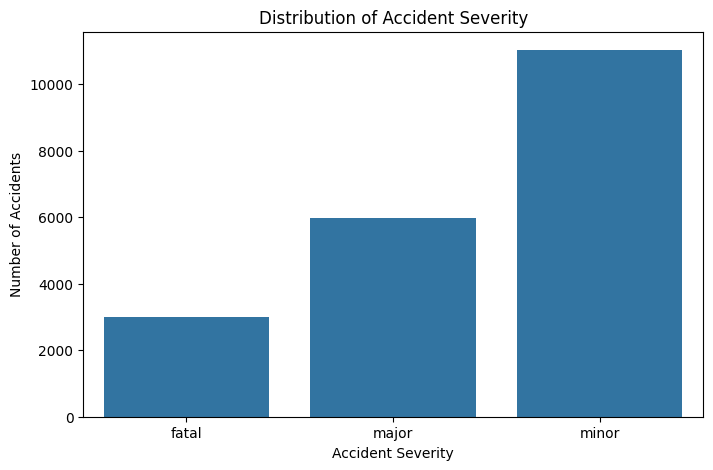

In [26]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df,
    x='accident_severity'
)
plt.title('Distribution of Accident Severity')
plt.xlabel('Accident Severity')
plt.ylabel('Number of Accidents')

plt.show()

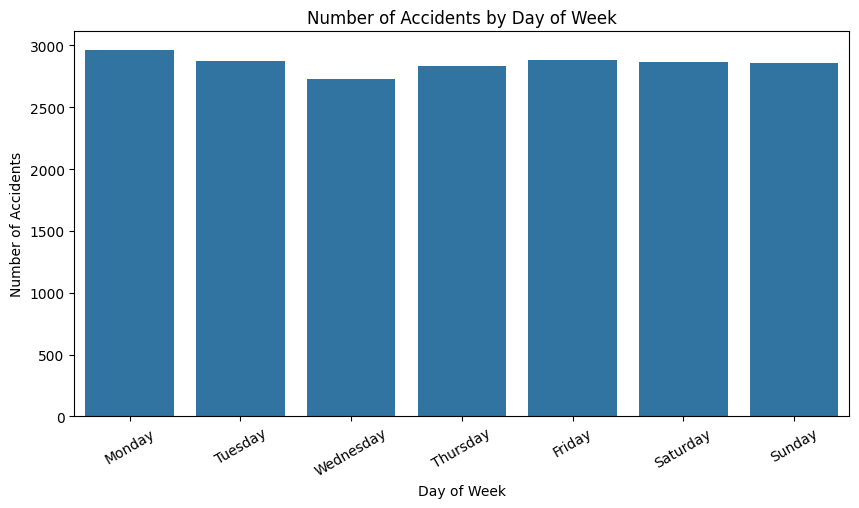

In [27]:
plt.figure(figsize=(10, 5))
sns.countplot(
    data=df,
    x='day_of_week',
    order=[
        'Monday',
        'Tuesday',
        'Wednesday',
        'Thursday',
        'Friday',
        'Saturday',
        'Sunday'
    ]
)

plt.title('Number of Accidents by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=30)

plt.show()

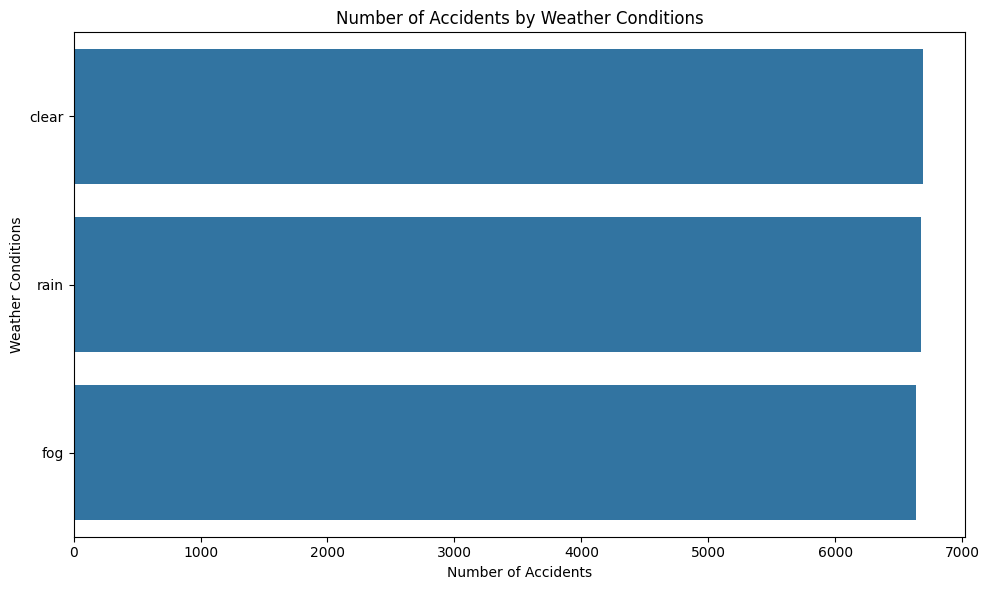

In [28]:
plt.figure(figsize=(10, 6))

weather_counts = df['weather'].value_counts()

sns.barplot(
    x=weather_counts.values,
    y=weather_counts.index
)

plt.title('Number of Accidents by Weather Conditions')
plt.xlabel('Number of Accidents')
plt.ylabel('Weather Conditions')

plt.tight_layout()
plt.show()